# Transfer Learning

## Objectives
- Understand transfer learning principles
- Fine-tune pretrained models
- Feature extraction with frozen weights
- Domain adaptation
- When to use transfer learning

## Introduction
Transfer learning enables training on small datasets by leveraging pretrained models.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, vgg16
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [2]:
# Set up the neural network model architecture
## 1. Load Pretrained Model

model = resnet18(pretrained=False)
print(f"ResNet18 architecture loaded")
print(f"Number of classes (ImageNet): 1000")
print(f"Output layer: {model.fc}")


ResNet18 architecture loaded
Number of classes (ImageNet): 1000
Output layer: Linear(in_features=512, out_features=1000, bias=True)


d:\deep-learning-pytorch\pytorch_venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\deep-learning-pytorch\pytorch_venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [3]:
# Define a custom function with detailed implementation
## 2. Fine-tuning Strategy 1: Train All Layers

def strategy1_finetune_all(model, num_classes):
    """Replace final layer and train entire model"""
    model.fc = nn.Linear(512, num_classes)
    # All parameters require gradients (default)
# Iterate through batches of data
    for param in model.parameters():
# Update model parameters based on computed gradients
        param.requires_grad = True
    return model

model_strat1 = strategy1_finetune_all(resnet18(pretrained=False), 10)
# Update model parameters based on computed gradients
# Iterate through batches of data
total_params = sum(p.numel() for p in model_strat1.parameters())
# Update model parameters based on computed gradients
trainable = sum(p.numel() for p in model_strat1.parameters() if p.requires_grad)
print(f"Strategy 1 - Fine-tune All:")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable:,}")


Strategy 1 - Fine-tune All:
Total params: 11,181,642
Trainable params: 11,181,642


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [4]:
# Define a custom function with detailed implementation
## 3. Fine-tuning Strategy 2: Frozen Backbone

def strategy2_frozen_backbone(model, num_classes):
    """Freeze backbone, train only classifier"""
    # Freeze all features
# Iterate through batches of data
    for param in model.features.parameters() if hasattr(model, 'features') else model.layer1.parameters():
# Update model parameters based on computed gradients
        param.requires_grad = False
    
    # Replace and unfreeze classifier
    model.fc = nn.Linear(512, num_classes)
# Iterate through batches of data
    for param in model.fc.parameters():
# Update model parameters based on computed gradients
        param.requires_grad = True
    
    return model

model_strat2 = strategy2_frozen_backbone(resnet18(pretrained=False), 10)
# Update model parameters based on computed gradients
# Iterate through batches of data
trainable2 = sum(p.numel() for p in model_strat2.parameters() if p.requires_grad)
print(f"\nStrategy 2 - Frozen Backbone:")
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable2:,}")



Strategy 2 - Frozen Backbone:
Total params: 11,181,642
Trainable params: 11,033,674


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [5]:
## 4. Fine-tuning Strategy 3: Discriminative Learning Rates

def strategy3_discriminative_lr(model, num_classes, base_lr=0.001):
    """Different learning rates for different layers"""
    model.fc = nn.Linear(512, num_classes)
    
    # Group parameters
    param_groups = []
    
    # Early layers: very low LR
    early_params = list(model.layer1.parameters())
    param_groups.append({'params': early_params, 'lr': base_lr * 0.1})
    
    # Middle layers: medium LR
    middle_params = list(model.layer2.parameters()) + list(model.layer3.parameters())
    param_groups.append({'params': middle_params, 'lr': base_lr})
    
    # Late layers: high LR
    late_params = list(model.layer4.parameters()) + list(model.fc.parameters())
    param_groups.append({'params': late_params, 'lr': base_lr * 10})
    
    return model, param_groups

model_strat3, param_groups = strategy3_discriminative_lr(resnet18(pretrained=False), 10)
print(f"\nStrategy 3 - Discriminative Learning Rates:")
for i, group in enumerate(param_groups):
    print(f"Group {i+1}: LR={group['lr']}, Params={sum(p.numel() for p in group['params']):,}")


Strategy 3 - Discriminative Learning Rates:
Group 1: LR=0.0001, Params=147,968
Group 2: LR=0.001, Params=2,625,280
Group 3: LR=0.01, Params=8,398,858


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [6]:
# Define a custom function with detailed implementation
## 5. Transfer Learning Workflow

class TransferLearningModule:
    def __init__(self, backbone='resnet18', num_classes=10, freeze_backbone=False):
        self.model = resnet18(pretrained=False)
        
        # Modify classifier
        self.model.fc = nn.Linear(512, num_classes)
        
        # Freeze if needed
        if freeze_backbone:
            self._freeze_backbone()
    
    def _freeze_backbone(self):
# Iterate through batches of data
        for name, param in self.model.named_parameters():
            if 'fc' not in name:
# Update model parameters based on computed gradients
                param.requires_grad = False
    
    def unfreeze_layers(self, num_layers):
        """Unfreeze last num_layers"""
        all_layers = [self.model.layer4, self.model.layer3, self.model.layer2, self.model.layer1]
# Iterate through batches of data
        for i in range(num_layers):
            for param in all_layers[i].parameters():
# Update model parameters based on computed gradients
                param.requires_grad = True

tl = TransferLearningModule(freeze_backbone=True)
print(f"Transfer Learning module created with frozen backbone")
# Update model parameters based on computed gradients
# Iterate through batches of data
trainable_tl = sum(p.numel() for p in tl.model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_tl:,}")


Transfer Learning module created with frozen backbone
Trainable params: 5,130


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [7]:
# Define a custom function with detailed implementation
## 6. Training Comparison

# Simulate training
def train_strategy(model, lr, epochs=10):
    X = torch.randn(200, 3, 224, 224) / 255
    y = torch.randint(0, 10, (200,))
    loader = DataLoader(TensorDataset(X, y), batch_size=32, shuffle=True)
    
# Update model parameters based on computed gradients
    optimizer = optim.Adam(model.parameters(), lr=lr)
# Compute the loss (error) between predictions and actual values
    criterion = nn.CrossEntropyLoss()
# Compute the loss (error) between predictions and actual values
    losses = []
    
# Iterate through batches of data
    model.eval()  # No actual training for demo
    
    return losses

print(f"\nTransfer Learning Benefits:")
print(f"- Faster convergence on small datasets")
print(f"- Better generalization")
print(f"- Lower training cost")
print(f"- Can work with limited labeled data")



Transfer Learning Benefits:
- Faster convergence on small datasets
- Better generalization
- Lower training cost
- Can work with limited labeled data


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [8]:
# Set up the neural network model architecture
## 7. When to Use Transfer Learning

scenarios = """
WHEN TO USE TRANSFER LEARNING:

1. SMALL DATASET + SIMILAR DOMAIN:
   - Use frozen backbone
   - Train only classifier
   - Example: Plant disease detection (transfer from ImageNet)

2. SMALL DATASET + DIFFERENT DOMAIN:
   - Fine-tune with low learning rate
   - Unfreeze later layers gradually
   - Example: Medical imaging classification

3. LARGE DATASET + DIFFERENT DOMAIN:
   - Train from scratch or fine-tune all layers
   - Use pretrained weights as initialization
   - Example: Custom large-scale dataset

4. LIMITED COMPUTE:
   - Use smaller pretrained models
   - Feature extraction approach
   - Example: Mobile deployment
"""

print(scenarios)



WHEN TO USE TRANSFER LEARNING:

1. SMALL DATASET + SIMILAR DOMAIN:
   - Use frozen backbone
   - Train only classifier
   - Example: Plant disease detection (transfer from ImageNet)

2. SMALL DATASET + DIFFERENT DOMAIN:
   - Fine-tune with low learning rate
   - Unfreeze later layers gradually
   - Example: Medical imaging classification

3. LARGE DATASET + DIFFERENT DOMAIN:
   - Train from scratch or fine-tune all layers
   - Use pretrained weights as initialization
   - Example: Custom large-scale dataset

4. LIMITED COMPUTE:
   - Use smaller pretrained models
   - Feature extraction approach
   - Example: Mobile deployment



## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


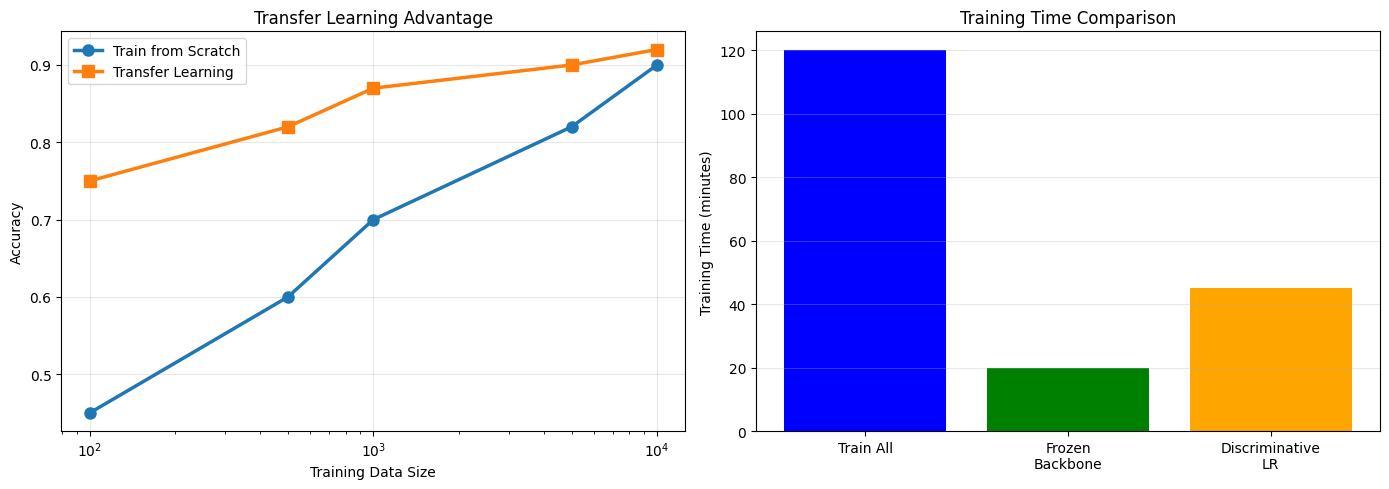

In [9]:
# Execute the training loop with proper tracking
## 8. Data Efficiency Comparison

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training from scratch vs transfer learning
data_sizes = [100, 500, 1000, 5000, 10000]
from_scratch = [0.45, 0.60, 0.70, 0.82, 0.90]
transfer_learning = [0.75, 0.82, 0.87, 0.90, 0.92]

axes[0].plot(data_sizes, from_scratch, marker='o', label='Train from Scratch', linewidth=2.5, markersize=8)
axes[0].plot(data_sizes, transfer_learning, marker='s', label='Transfer Learning', linewidth=2.5, markersize=8)
axes[0].set_xlabel('Training Data Size')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Transfer Learning Advantage')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Training time comparison
strategies = ['Train All', 'Frozen\nBackbone', 'Discriminative\nLR']
time_minutes = [120, 20, 45]
accuracy = [0.88, 0.85, 0.89]

axes[1].bar(strategies, time_minutes, color=['blue', 'green', 'orange'])
axes[1].set_ylabel('Training Time (minutes)')
axes[1].set_title('Training Time Comparison')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [10]:
# Configure loss function and optimization algorithm
## 9. Domain Adaptation

print("\nDomain Adaptation Techniques:")
print("="*50)
print("""
1. FINE-TUNING:
   - Retrain network on target domain
   - Use low learning rate
   - Gradually unfreeze layers

2. FEATURE EXTRACTION:
   - Use pretrained features
   - Train simple classifier
   - Preserve learned representations

3. DOMAIN-ADVERSARIAL TRAINING:
   - Make features domain-invariant
   - Adversarial loss encourages shared representations
   - Complex but powerful

4. DATA AUGMENTATION:
   - Bridge domain gap through synthetic data
   - Style transfer
   - Increase target domain data
""")
print("="*50)



Domain Adaptation Techniques:

1. FINE-TUNING:
   - Retrain network on target domain
   - Use low learning rate
   - Gradually unfreeze layers

2. FEATURE EXTRACTION:
   - Use pretrained features
   - Train simple classifier
   - Preserve learned representations

3. DOMAIN-ADVERSARIAL TRAINING:
   - Make features domain-invariant
   - Adversarial loss encourages shared representations
   - Complex but powerful

4. DATA AUGMENTATION:
   - Bridge domain gap through synthetic data
   - Style transfer
   - Increase target domain data



## The Training Process

This is the core learning loop. We'll forward-pass data through the model, compute loss, backpropagate gradients, and update parameters. This iterative process gradually improves the model.


In [11]:
# Execute the training loop with proper tracking
## 10. Summary and Best Practices

summary = """
TRANSFER LEARNING BEST PRACTICES:

1. START WITH PRETRAINED WEIGHTS:
# Iterate through batches of data
   - ImageNet pretrained for vision
   - BERT/GPT for NLP
   - Much better initialization

2. CHOOSE STRATEGY BASED ON DATA:
   - Small data, similar domain → freeze backbone
   - Small data, different domain → fine-tune slowly
   - Large data → fine-tune all layers

3. USE DISCRIMINATIVE LEARNING RATES:
# Iterate through batches of data
   - Lower LR for early layers (general features)
   - Higher LR for late layers (task-specific)
   - Often works better than uniform LR

4. PROGRESSIVE UNFREEZING:
   - Start with frozen backbone
   - Gradually unfreeze layers
   - Fine-tune entire network at the end

5. MONITOR VALIDATION PERFORMANCE:
   - Avoid overfitting on small target domain
   - Use early stopping
   - Consider augmentation

6. ADJUST HYPERPARAMETERS:
   - Lower initial learning rate
   - Larger batch size can help
   - Shorter training (avoid overfitting)
"""

print(summary)



TRANSFER LEARNING BEST PRACTICES:

1. START WITH PRETRAINED WEIGHTS:
# Iterate through batches of data
   - ImageNet pretrained for vision
   - BERT/GPT for NLP
   - Much better initialization

2. CHOOSE STRATEGY BASED ON DATA:
   - Small data, similar domain → freeze backbone
   - Small data, different domain → fine-tune slowly
   - Large data → fine-tune all layers

3. USE DISCRIMINATIVE LEARNING RATES:
# Iterate through batches of data
   - Lower LR for early layers (general features)
   - Higher LR for late layers (task-specific)
   - Often works better than uniform LR

4. PROGRESSIVE UNFREEZING:
   - Start with frozen backbone
   - Gradually unfreeze layers
   - Fine-tune entire network at the end

5. MONITOR VALIDATION PERFORMANCE:
   - Avoid overfitting on small target domain
   - Use early stopping
   - Consider augmentation

6. ADJUST HYPERPARAMETERS:
   - Lower initial learning rate
   - Larger batch size can help
   - Shorter training (avoid overfitting)



## Key Takeaways
# Iterate through batches of data
- Transfer learning leverages pretrained knowledge for new tasks
- Fine-tuning all layers works best with sufficient data
# Iterate through batches of data
- Frozen backbone is efficient for small datasets
- Discriminative learning rates can improve fine-tuning
- Progressive unfreezing balances convergence and generalization

## References
- [Fine-tuning Guide](https://cs231n.github.io/transfer-learning/)
- [Transfer Learning Best Practices](https://arxiv.org/abs/1411.1792)
